<a href="https://colab.research.google.com/github/DinaKSari/244107020072_PEMBELAJARAN_MESIN/blob/main/KUIS1_244107020072_DINA_KUMALA_SARI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Langkah 1: Setup & Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Langkah 2: Load Dataset


In [ ]:
# Memuat dataset dengan encoding latin1
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')

print(f"Total data awal: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Total data awal: 3169 baris, 9 kolom


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


### Informasi & Eksplorasi Dataset Awal

In [ ]:
import pandas as pd
print("Ukuran Dataset:", df.shape)
print("\nNama Kolom:", df.columns.tolist())
print("\nInformasi Dataset:")
df.info()
print("\nJumlah Missing Value:")
print(df.isnull().sum())

Ukuran Dataset: (3169, 9)

Nama Kolom: ['Plant_ID', 'Date', 'Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days', 'Temperature (F)', 'Humidity']

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plant_ID          3169 non-null   int64  
 1   Date              3169 non-null   object 
 2   Temperature (°C)  3169 non-null   float64
 3   Humidity (%)      3169 non-null   int64  
 4   TDS Value (ppm)   3169 non-null   int64  
 5   pH Level          3169 non-null   float64
 6   Growth Days       3169 non-null   int64  
 7   Temperature (F)   3169 non-null   float64
 8   Humidity          3169 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 222.9+ KB

Jumlah Missing Value:
Plant_ID            0
Date                0
Temperature (°C)    0
Humidity (%)        0
TDS Value

# Langkah 3: Preprocessing + Fungsi Pembagian Data

In [ ]:
# 1. Seleksi fitur
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
X_raw = df[features]

# 2. Standarisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
df_scaled = pd.DataFrame(X_scaled, columns=features)

# 3. Fungsi Pembagian Data (100%, 80%, 50%, 30%)
def get_data_splits(data):
    splits = {
        "Full Data (100%)": data.values,
        "80% Data": data.sample(frac=0.8, random_state=42).values,
        "50% Data": data.sample(frac=0.5, random_state=42).values,
        "30% Data": data.sample(frac=0.3, random_state=42).values
    }
    return splits

data_splits = get_data_splits(df_scaled)

for name, data in data_splits.items():
    print(f"{name}: {len(data)} baris")

Full Data (100%): 3169 baris
80% Data: 2535 baris
50% Data: 1584 baris
30% Data: 951 baris


# Langkah 4: Euclidean Distance (K-Means)

In [ ]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iters=100, metric='euclidean'):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.metric = metric
        self.centroids = None
        self.labels = None
        self.inertia_ = 0

    def fit(self, X):
        np.random.seed(42)
        random_idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            distances = cdist(X, self.centroids, metric=self.metric)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.zeros((self.n_clusters, X.shape[1]))
            for i in range(self.n_clusters):
                cluster_data = X[self.labels == i]
                if len(cluster_data) > 0:
                    new_centroids[i] = np.mean(cluster_data, axis=0) # Euclidean = Mean
                else:
                    new_centroids[i] = self.centroids[i]

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        # Hitung Inertia (SSE) untuk Euclidean
        final_dist = cdist(X, self.centroids, metric=self.metric)
        min_dist = np.min(final_dist, axis=1)
        self.inertia_ = np.sum(min_dist**2)

        return self

# Langkah 5: Elbow Method

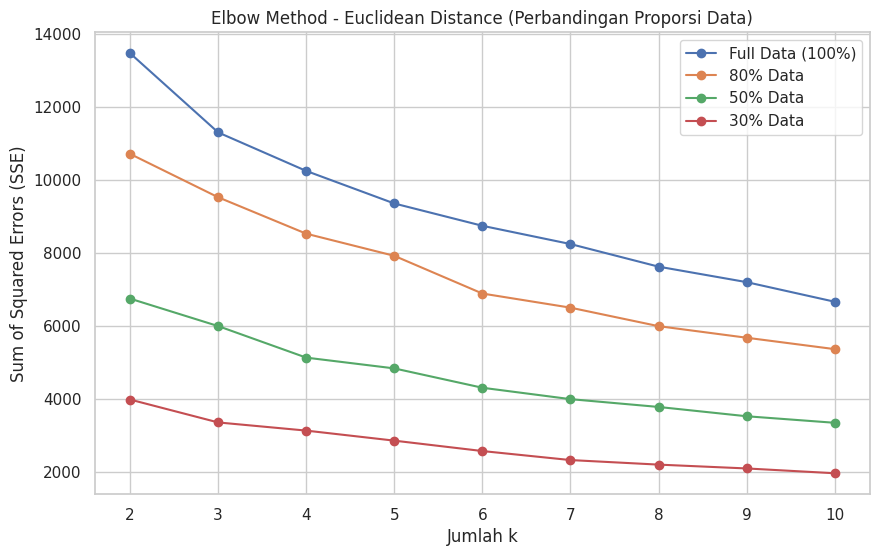

In [ ]:
plt.figure(figsize=(10, 6))
K_range = range(2, 11)

for name, X_data in data_splits.items():
    sse = []
    for k in K_range:
        model = CustomKMeans(n_clusters=k, metric='euclidean')
        model.fit(X_data)
        sse.append(model.inertia_)
    plt.plot(K_range, sse, marker='o', label=name)

plt.xlabel('Jumlah k')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method - Euclidean Distance (Perbandingan Proporsi Data)')
plt.legend()
plt.xticks(K_range)
plt.show()

# Hasil

Jumlah k yang saya gunakan berdasarkan elbow method dan Silhouette score adalah 4. Dikarenakan mempunyai nilai silhouette score yang paling stabil terhadap perubahan data.

# Langkah 6: Clustering Final + Metrik Evaluasi

In [ ]:
k_optimal = 4
euclidean_results = {}

print(f"Hasil Evaluasi Euclidean Distance (k= {k_optimal})")
for name, X_data in data_splits.items():
    model = CustomKMeans(n_clusters=k_optimal, metric='euclidean')
    model.fit(X_data)

    # Silhouette Score
    score = silhouette_score(X_data, model.labels, metric='euclidean')
    euclidean_results[name] = score

    print(f"{name:<20} | Silhouette Score: {score:.4f} | Inertia: {model.inertia_:.2f}")

Hasil Evaluasi Euclidean Distance (k= 4)
Full Data (100%)     | Silhouette Score: 0.1547 | Inertia: 10258.11
80% Data             | Silhouette Score: 0.1527 | Inertia: 8538.81
50% Data             | Silhouette Score: 0.1576 | Inertia: 5143.96
30% Data             | Silhouette Score: 0.1775 | Inertia: 3144.81


# Langkah 7: Visualisasi Pca 2D Pemetaan Klaster

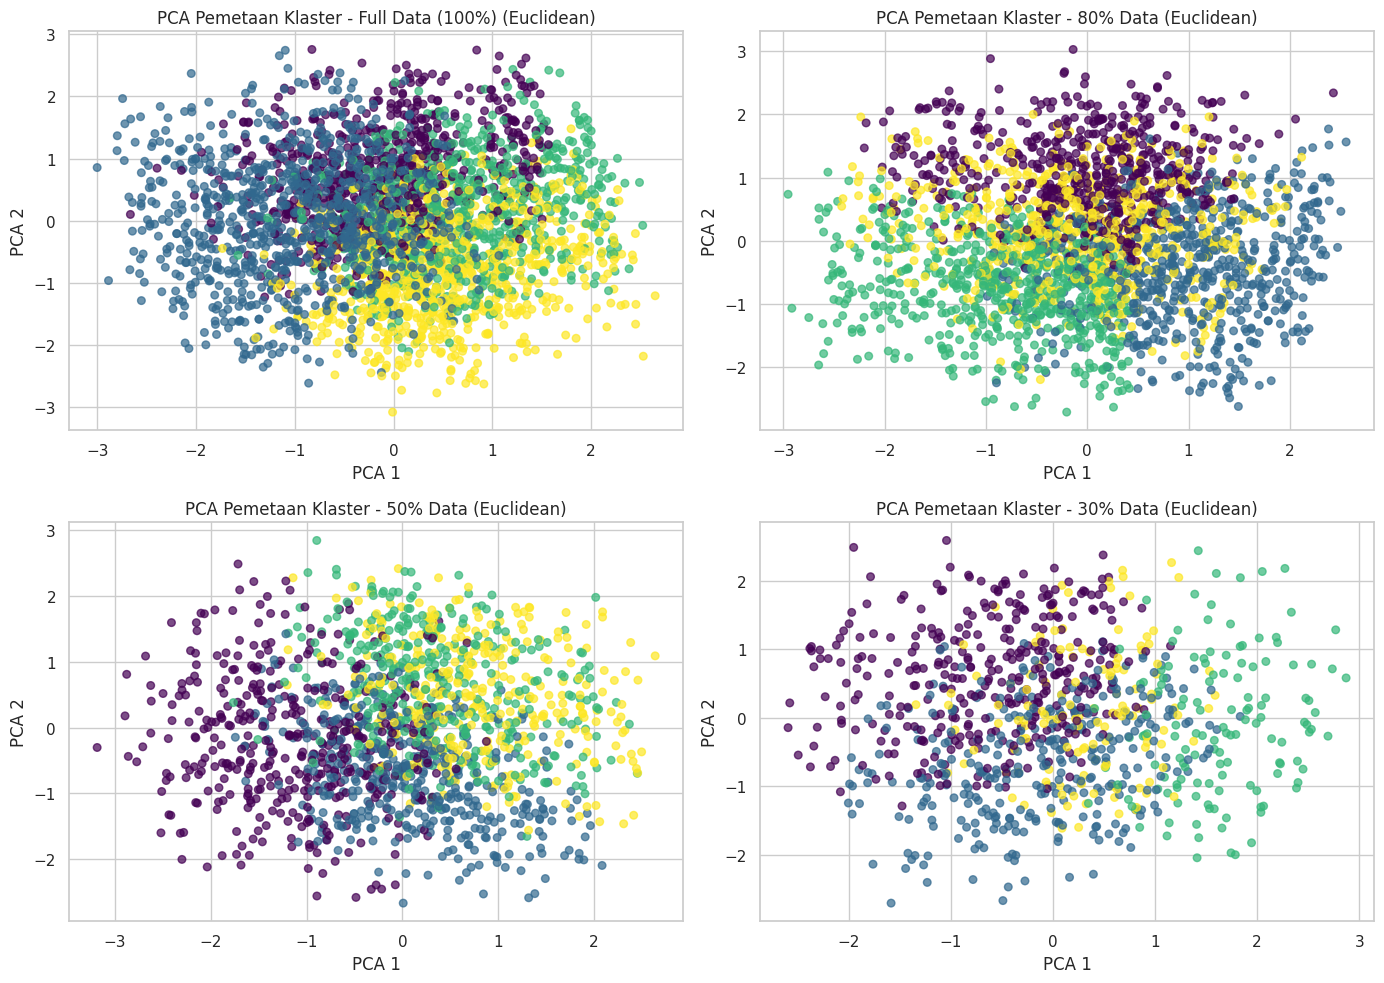

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, X_data) in enumerate(data_splits.items()):
    model = CustomKMeans(n_clusters=k_optimal, metric='euclidean')
    model.fit(X_data)

    # Reduksi Dimensi ke 2D menggunakan PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=model.labels, cmap='viridis', s=30, alpha=0.7)
    axes[idx].set_title(f'PCA Pemetaan Klaster - {name} (Euclidean)')
    axes[idx].set_xlabel('PCA 1')
    axes[idx].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

# Langkah 8: Grafik Bar Perbandingan Metrik

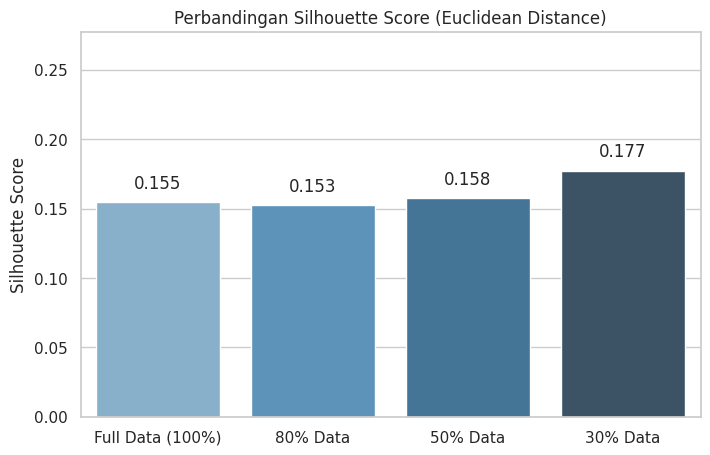

In [ ]:
names = list(euclidean_results.keys())
scores = list(euclidean_results.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=names, y=scores, palette='Blues_d')
plt.title('Perbandingan Silhouette Score (Euclidean Distance)')
plt.ylabel('Silhouette Score')
plt.ylim(0, max(scores) + 0.1)

for i, score in enumerate(scores):
    plt.text(i, score + 0.01, f'{score:.3f}', ha='center')

plt.show()

# Metode Manhattan Distance

# Langkah 1: Setup & Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Langkah 2: Load Dataset

In [ ]:
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')
print(f"Total data awal: {df.shape[0]} baris, {df.shape[1]} kolom")

Total data awal: 3169 baris, 9 kolom


# Langkah 3: Preprocessing + Fungsi Pembagian Data

In [ ]:
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
X_raw = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
df_scaled = pd.DataFrame(X_scaled, columns=features)

def get_data_splits(data):
    splits = {
        "Full Data (100%)": data.values,
        "80% Data": data.sample(frac=0.8, random_state=42).values,
        "50% Data": data.sample(frac=0.5, random_state=42).values,
        "30% Data": data.sample(frac=0.3, random_state=42).values
    }
    return splits

data_splits = get_data_splits(df_scaled)

# Langkah 4: Manhattan Distance (K-Medians)

In [ ]:
class CustomKMedians:
    def __init__(self, n_clusters=3, max_iters=100, metric='cityblock'):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.metric = metric
        self.centroids = None
        self.labels = None
        self.inertia_ = 0

    def fit(self, X):
        np.random.seed(42)
        random_idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            distances = cdist(X, self.centroids, metric=self.metric)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.zeros((self.n_clusters, X.shape[1]))
            for i in range(self.n_clusters):
                cluster_data = X[self.labels == i]
                if len(cluster_data) > 0:
                    new_centroids[i] = np.median(cluster_data, axis=0)
                else:
                    new_centroids[i] = self.centroids[i]

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        # Hitung Error absolut
        final_dist = cdist(X, self.centroids, metric=self.metric)
        self.inertia_ = np.sum(np.min(final_dist, axis=1))

        return self

# Langkah 5: Elbow Method


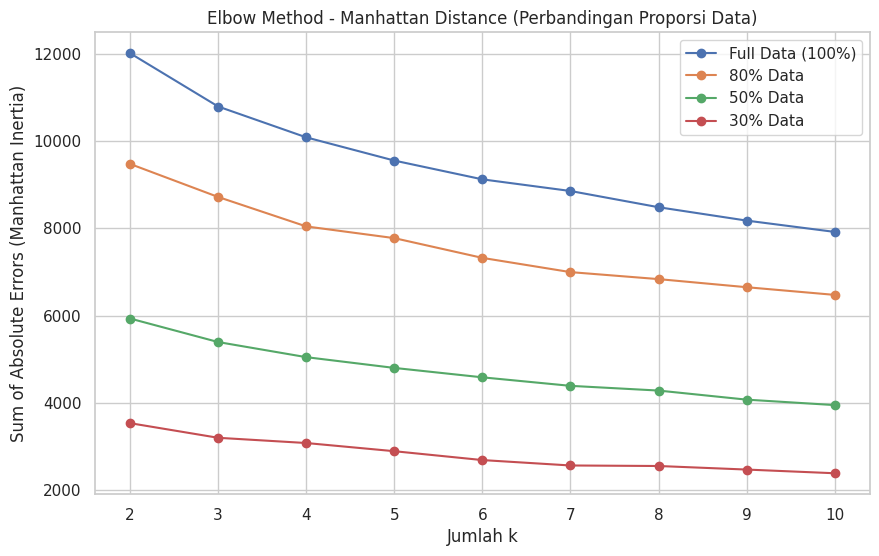

In [ ]:
plt.figure(figsize=(10, 6))
K_range = range(2, 11)

for name, X_data in data_splits.items():
    sse = []
    for k in K_range:
        model = CustomKMedians(n_clusters=k, metric='cityblock')
        model.fit(X_data)
        sse.append(model.inertia_)
    plt.plot(K_range, sse, marker='o', label=name)

plt.xlabel('Jumlah k')
plt.ylabel('Sum of Absolute Errors (Manhattan Inertia)')
plt.title('Elbow Method - Manhattan Distance (Perbandingan Proporsi Data)')
plt.legend()
plt.xticks(K_range)
plt.show()

### Hasil Evaluasi Nilai k
Berdasarkan elbow method dan score silhouette, saya menggunakan nilai k = 6. Karena paling stabil dan score nya juga lebih mendekati 1

# Langkah 6: Clustering Final + Metrik Evaluasi

In [ ]:
k_optimal = 6
manhattan_results = {}

print(f"Hasil Evaluasi Manhattan Distance (k= {k_optimal})")
for name, X_data in data_splits.items():
    model = CustomKMedians(n_clusters=k_optimal, metric='cityblock')
    model.fit(X_data)

    # Silhouette Score dihitung menggunakan metrik manhattan (cityblock)
    score = silhouette_score(X_data, model.labels, metric='cityblock')
    manhattan_results[name] = score

    print(f"{name:<20} | Silhouette Score: {score:.4f} | Absolute Error: {model.inertia_:.2f}")

Hasil Evaluasi Manhattan Distance (k= 6)
Full Data (100%)     | Silhouette Score: 0.1518 | Absolute Error: 9123.38
80% Data             | Silhouette Score: 0.1621 | Absolute Error: 7324.62
50% Data             | Silhouette Score: 0.1630 | Absolute Error: 4588.92
30% Data             | Silhouette Score: 0.1672 | Absolute Error: 2693.73


# Langkah 7: Visualisasi Pca 2D Pemetaan Klaster


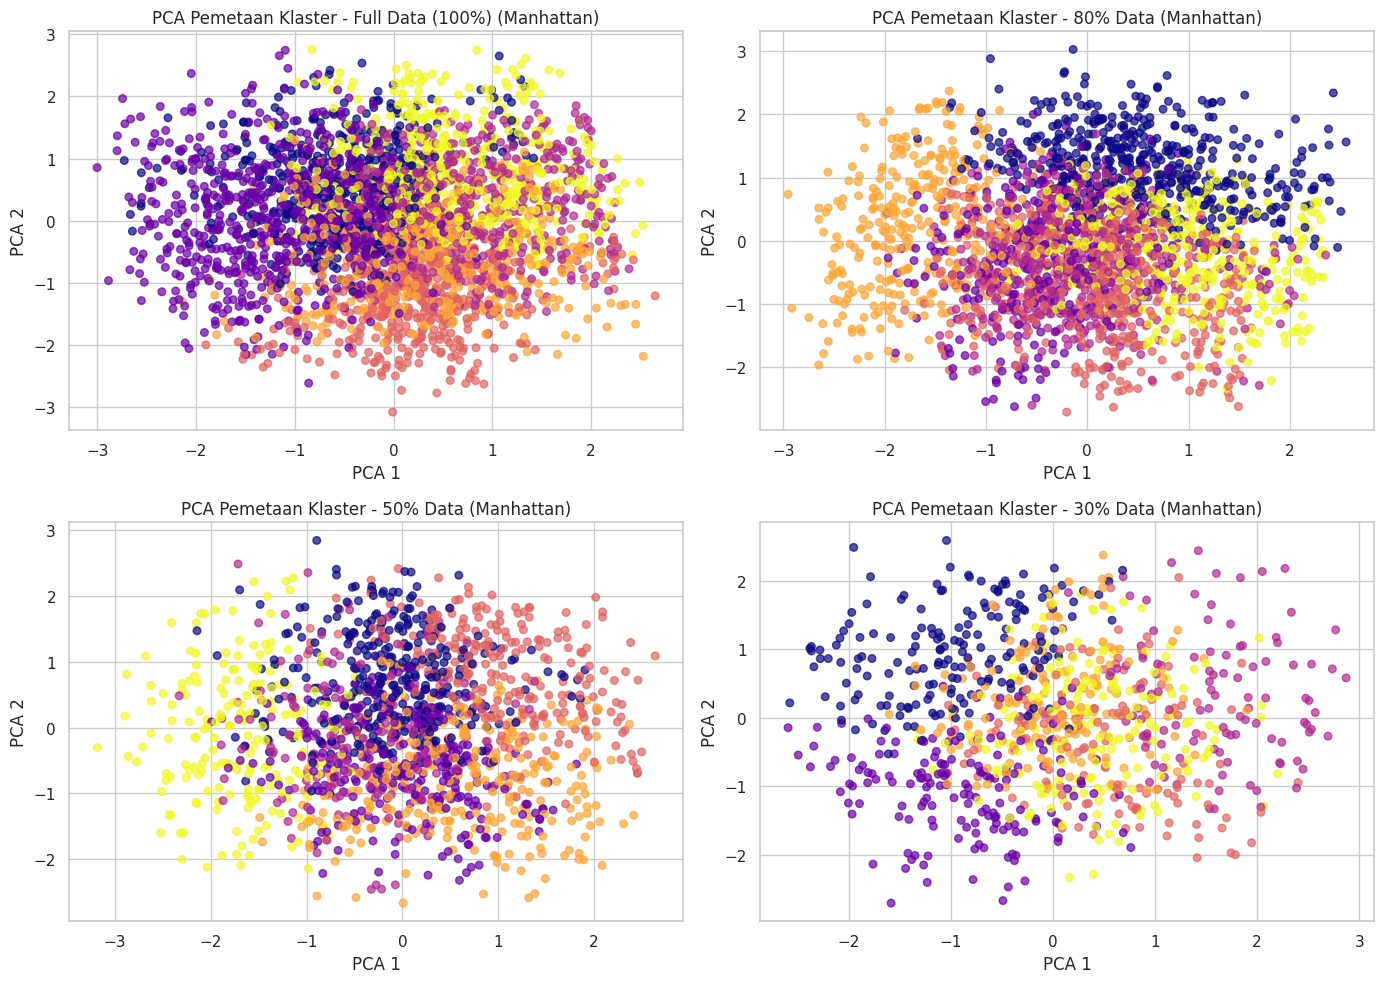

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, X_data) in enumerate(data_splits.items()):
    model = CustomKMedians(n_clusters=k_optimal, metric='cityblock')
    model.fit(X_data)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=model.labels, cmap='plasma', s=30, alpha=0.7)
    axes[idx].set_title(f'PCA Pemetaan Klaster - {name} (Manhattan)')
    axes[idx].set_xlabel('PCA 1')
    axes[idx].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

# Langkah 8: Grafik Bar Perbandingan Metrik


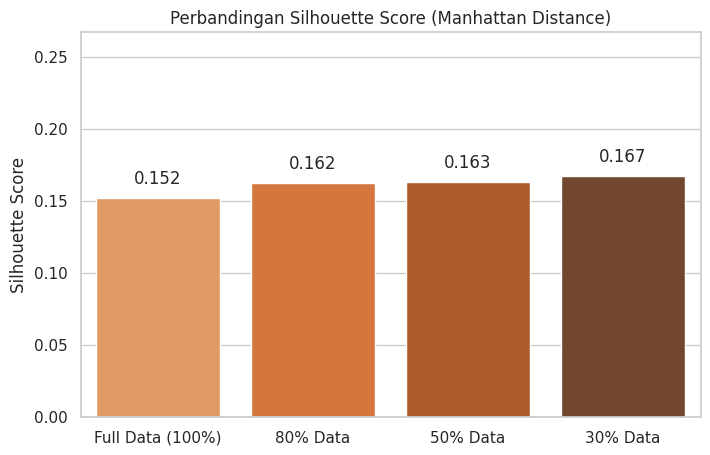

In [ ]:
names = list(manhattan_results.keys())
scores = list(manhattan_results.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=names, y=scores, palette='Oranges_d')
plt.title('Perbandingan Silhouette Score (Manhattan Distance)')
plt.ylabel('Silhouette Score')
plt.ylim(0, max(scores) + 0.1)

for i, score in enumerate(scores):
    plt.text(i, score + 0.01, f'{score:.3f}', ha='center')

plt.show()

# Cosine Similarity

In [ ]:
# Langkah 1: Setup & Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [ ]:
# Langkah 2: Load Dataset
df = pd.read_csv('lettuce_dataset_updated.csv', encoding='latin1')
print(f"Total data awal: {df.shape[0]} baris, {df.shape[1]} kolom")

In [ ]:
# Langkah 3: Preprocessing + Fungsi Pembagian Data
features = ['Temperature (°C)', 'Humidity (%)', 'TDS Value (ppm)', 'pH Level', 'Growth Days']
X_raw = df[features]

# Standarisasi dilanjutkan dengan Normalisasi L2 (Penting untuk Spherical K-Means/Cosine)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

normalizer = Normalizer(norm='l2')
X_norm = normalizer.fit_transform(X_scaled)
df_norm = pd.DataFrame(X_norm, columns=features)

def get_data_splits(data):
    splits = {
        "Full Data (100%)": data.values,
        "80% Data": data.sample(frac=0.8, random_state=42).values,
        "50% Data": data.sample(frac=0.5, random_state=42).values,
        "30% Data": data.sample(frac=0.3, random_state=42).values
    }
    return splits

data_splits = get_data_splits(df_norm)

In [ ]:
# Langkah 4: Kelas Spherical K Means (Cosine Distance)
class CustomKMeansCosine:
    def __init__(self, n_clusters=3, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.metric = 'cosine'
        self.centroids = None
        self.labels = None
        self.inertia_ = 0

    def fit(self, X):
        np.random.seed(42)
        random_idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            distances = cdist(X, self.centroids, metric=self.metric)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.zeros((self.n_clusters, X.shape[1]))
            for i in range(self.n_clusters):
                cluster_data = X[self.labels == i]
                if len(cluster_data) > 0:
                    mean_vec = np.mean(cluster_data, axis=0)
                    # Wajib: Normalisasi centroid kembali ke panjang 1 untuk Spherical K-Means
                    norm = np.linalg.norm(mean_vec)
                    new_centroids[i] = mean_vec / norm if norm > 0 else mean_vec
                else:
                    new_centroids[i] = self.centroids[i]

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        # Hitung Inertia (Total error dari Cosine Distance)
        final_dist = cdist(X, self.centroids, metric=self.metric)
        self.inertia_ = np.sum(np.min(final_dist, axis=1))

        return self

In [ ]:
# Langkah 5: Elbow Method
plt.figure(figsize=(10, 6))
K_range = range(2, 11)

for name, X_data in data_splits.items():
    sse = []
    for k in K_range:
        model = CustomKMeansCosine(n_clusters=k)
        model.fit(X_data)
        sse.append(model.inertia_)
    plt.plot(K_range, sse, marker='o', label=name)

plt.xlabel('Jumlah k')
plt.ylabel('Sum of Cosine Distances (Inertia)')
plt.title('Elbow Method - Cosine Distance (Perbandingan Proporsi Data)')
plt.legend()
plt.xticks(K_range)
plt.show()

In [ ]:
# Langkah 6: Clustering Final + Metrik Evaluasi
k_optimal = 4 # Ganti dengan hasil k terbaik dari grafik elbow kamu
cosine_results = {}

print(f"=== Hasil Evaluasi Cosine Distance (k={k_optimal}) ===")
for name, X_data in data_splits.items():
    model = CustomKMeansCosine(n_clusters=k_optimal)
    model.fit(X_data)

    # Silhouette Score dihitung menggunakan metrik cosine
    score = silhouette_score(X_data, model.labels, metric='cosine')
    cosine_results[name] = score

    print(f"{name:<20} | Silhouette Score: {score:.4f} | Inertia: {model.inertia_:.2f}")

In [ ]:
# Langkah 7: Visualisasi Pca 2D Pemetaan Klaster
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, X_data) in enumerate(data_splits.items()):
    model = CustomKMeansCosine(n_clusters=k_optimal)
    model.fit(X_data)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=model.labels, cmap='coolwarm', s=30, alpha=0.7)
    axes[idx].set_title(f'PCA Pemetaan Klaster - {name} (Cosine)')
    axes[idx].set_xlabel('PCA 1')
    axes[idx].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

In [ ]:
# Langkah 8: Grafik Bar Perbandingan Metrik
names = list(cosine_results.keys())
scores = list(cosine_results.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=names, y=scores, palette='Purples_d')
plt.title('Perbandingan Silhouette Score (Cosine Similarity)')
plt.ylabel('Silhouette Score')
plt.ylim(0, max(scores) + 0.1)

for i, score in enumerate(scores):
    plt.text(i, score + 0.01, f'{score:.3f}', ha='center')

plt.show()